# Langevin State-Space Model Inference (§5.2)

Reproduces the **Langevin model inference** experiments of Lin & Godsill (2025), *Bayesian Non-Parametric Inference for Lévy Measures in State-Space Models* ([arXiv:2505.22587](https://arxiv.org/abs/2505.22587)).

The state-space model is a linear **Langevin** system driven by an NVM process and observed in Gaussian noise — a setting where the driving Lévy process is *latent* and only noisily and partially observed. Using the IGSDP prior we jointly infer the NVM Lévy measure, the latent states, and the system parameter $\theta$.

**Experiments in this notebook**
1. Tempered-stable-driven NVM in the Langevin model
2. Bimodal subordinator-driven NVM in the Langevin model

**Data / outputs.** Loads the simulated datasets `TS_driven_NVM.npz` and `bimodal_driven_NVM.npz`. The MCMC posterior samples are written to large `*.npz` archives (git-ignored) and reloaded for plotting; regenerate them by running the sampling cells. The runs are heavy — reduce `burn_in` / iteration counts for a quick pass.

## Tempered Stable driven NVM in Langevin Model

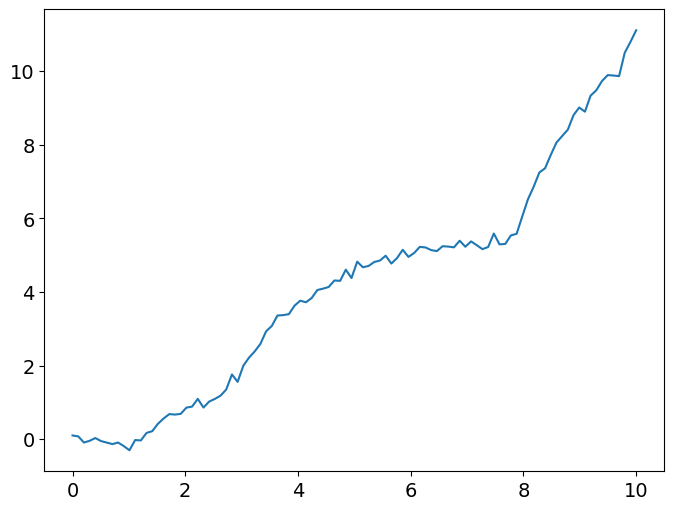

The conditional sigmaw2 = 1.0


In [1]:
#Load the observations
# Load the saved data, including the initial jump sizes and times here
#The initialization is through random generation of a set of subordinator series
import numpy as np
from scipy.linalg import expm #This is the automatic matrix expnent solver
import math
import seaborn as sns
from scipy.special import logsumexp
from numba import jit
import matplotlib.pyplot as plt
from tqdm import tqdm
from posteriors import*
from Common_Tools import*
from Levy_Generators import*
from Levy_State_Space import*
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation, PillowWriter
from mcmc_sampler import*
from ground_truths import*
from mcmc_sampler_sigmaw2_conditional import *
plt.rcParams.update({
    "figure.figsize": (8, 6),  # overall figure size
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

data = np.load("TS_driven_NVM.npz")
sim_rate = data["sim_rate"]
T = data["T"]
time_axis = data["time_axis"]
beta = data["beta"]
alpha = data["alpha"]
C = data["C"]
muw = data["muw"]
sigmaw = data["sigmaw"]
kv = data["kv"]
theta = data["theta"]
sub_jump_sizes = data["sub_jump_sizes"]
jump_times = data["jump_times"]
original_path = data["original_path"]
nvm_jump_sizes = data["nvm_jump_sizes"]
langevin_path = data["langevin_path"]
true_x = data["true_x"]
true_x_dot = data["true_x_dot"]





#Re-create the observations with new noise level
observation_noise_level = 0.1
full_observations = langevin_observations(langevin_path,(observation_noise_level**2)*np.identity(2))
observations = np.zeros((1,np.shape(full_observations)[1]))
observations[0,:] = full_observations[0,:]



plt.figure()
plt.plot(time_axis,observations[0,:])
plt.show()

#Convert first the parameters loaded into our convention for the sigmaw2 conditinal experiments
sigmaw2 = sigmaw ** 2
sigmav2 = kv * sigmaw ** 2


sigmaw2 = sigmaw2
print(f"The conditional sigmaw2 = {sigmaw2}")

In [ ]:
#Extended MCMC Algorithm with Hyper-parameter Sampling
#Inference Parameters
burn_in = 200000
num_iter = 400000
block_width = 20
overlapping_width = 10
#shape rate convention here
rate_alpha_prior = 3 #Gamma base distirbution for the Dirichlet process prior
rate_beta_prior = 1
#dir_alpha = 2 #Can be understood as 10 observations from the base Gamma distribution
dir_K = 1000
#DP hyper-parameter prior or initialization definition
initial_dir_alpha = 2.0
initial_base_gamma_a = 1
initial_base_gamma_b= 2

#Shape-scale convention here.
dir_alpha_a = 1.0
dir_alpha_b = 3.0

base_gamma_a_mean = initial_base_gamma_a
base_gamma_a_std = 1000.0
base_gamma_b_mean = initial_base_gamma_b
base_gamma_b_std = 1000.0
base_gamma_a_step_size = 0.0
base_gamma_b_step_size = 0.0

#Defining the theta prior and the GRW proposal step size
theta_prior = theta * 1.0
theta_step_size = observation_noise_level * 3 #This is the factor applied to the standard deviation. Square it to apply it to the variance.

#Generate Initilisation of the jump sizes
wrong_beta = 1*beta
wrong_alpha = alpha
wrong_C = 1*C

initial_jump_sizes,initial_jump_times = tempered_stable_process_jumps((wrong_beta,wrong_alpha,wrong_C),T,sim_rate)

#grouped_jump_sizes,grouped_jump_times = group_jumps(initial_jump_sizes,initial_jump_times,time_axis)
#prior_path = integrate_to_path(initial_jump_sizes,initial_jump_times,time_axis)
# initial_jump_sizes = sub_jump_sizes
# initial_jump_times = jump_times
grouped_jump_sizes,grouped_jump_times = group_jumps(initial_jump_sizes,initial_jump_times,time_axis)
prior_path = original_path

prior_muw_mean = 0.0
prior_muw_variance = 10.0

sample_measures,sample_rates,sample_paths,sample_thetas,overall_theta_acceptance_probability,sample_x_means,sample_x_covariances,dir_alphas,base_gamma_as,base_gamma_bs,sample_smoothed_means,sampled_smoothed_covariances = langevin_lm_theta_inference_all_DP_alpha_inferred_Gamma_base_Gaussian_update_conditional_sigmaw2(num_iter,block_width,overlapping_width,observations,time_axis,initial_jump_sizes,initial_jump_times,sigmav2,rate_alpha_prior,rate_beta_prior,dir_K,dir_alpha_a,dir_alpha_b,base_gamma_a_mean,base_gamma_a_std,base_gamma_b_mean,base_gamma_b_std,sigmaw2,theta_prior,theta_step_size,base_gamma_a_step_size,base_gamma_b_step_size,dir_alpha=initial_dir_alpha,base_gamma_a=initial_base_gamma_a,base_gamma_b=initial_base_gamma_b,muw_prior_mean = prior_muw_mean,muw_prior_variance=prior_muw_variance,compute_smoothing=True)

#Discard the burn-in
sample_measures = sample_measures[burn_in:]
sample_rates = sample_rates[burn_in:]
sample_paths = sample_paths[burn_in:]
sample_thetas = sample_thetas[burn_in:]
sample_x_means = sample_x_means[burn_in:]
sample_x_covariances = sample_x_covariances[burn_in:]
sample_smoothed_means = sample_smoothed_means[burn_in:]
sample_smoothed_covariances = sampled_smoothed_covariances[burn_in:]


np.savez(
    "langevin_ts_sigmaw2_conditional.npz",
    sample_measures=sample_measures,
    sample_rates=sample_rates,
    sample_paths=sample_paths,
    sample_thetas=sample_thetas,
    sample_x_means=sample_x_means,
    sample_x_covariances=sample_x_covariances,
    overall_theta_acceptance_probability = overall_theta_acceptance_probability,
    sample_smoothed_means=sample_smoothed_means,
    sample_smoothed_covariances = sample_smoothed_covariances,
)


#The Posterior Analysis Session
overall_rates_list = []
overall_positions_list = []
#NVM_ground_truth_conditional_densities = []
#overall_NVM_ground_truth_discrete_rates = []
#overall_NVM_ground_truth_discrete_positions = []
#NVM_conditional_densities = []
NVM_conditional_lower_tails = []
NVM_conditional_upper_tails = []
overall_NVM_discrete_rates = []
overall_NVM_discrete_positions = []
#Define the posterior analysis axis
epsilon = 1e-5 #The minimum valku for the x axis of the upper tail function. This cannot go to 0 for stability reason
x_axis = np.logspace(np.log10(epsilon),np.log10(5),1000) #Change the resolution parameter here to change the bin density
# Combine the negative and positive parts to form the nvm_axis
nvm_positive_axis = np.logspace(np.log10(epsilon),np.log10(5),100)
nvm_negative_axis =np.logspace(np.log10(epsilon),np.log10(3),100)
nvm_axis = np.concatenate([-nvm_negative_axis[::-1], nvm_positive_axis])
sample_upper_tail_measures = []
#effective_component_numbers = []

#jump_dist_entropies = []
# Averaging the sample measures
# Combining the rate and jump size distribution into the Levy measure

for i in tqdm(range(len(sample_measures)),desc="Posterior Analysis"):#Iterating over the samples in each iteration
    sample_rate = sample_rates[i]
    sample_measure = sample_measures[i]  # 2 x K
    #jump_dist_entropies.append(compute_entropy(sample_measure[0, :]))
    #probabilities = sample_measure[0,:]

    sample_measure[0, :] = sample_measure[0, :] * sample_rate  # K-dimensional array. Combining the rate and jump size distributioin into the Levy density
    sample_measures[i] = sample_measure
    #Then extract the information from the L\'evy density
    rates = sample_measure[0, :]
    positions = sample_measure[1, :]
    #Compute and store the upper tail measure function values on the x axis defined
    sample_upper_tail_measure = DP_upper_tail_projection(positions,rates,x_axis)
    sample_upper_tail_measures.append(sample_upper_tail_measure)
    # Collect arrays in lists
    overall_rates_list.append(rates)
    overall_positions_list.append(positions)
    #Posterior Analysis of the samples
    # x_mean_sample_series = sample_x_means[i] #The mean series inferred by the Kalman filter 
    # x_covariance_sample_series = sample_x_covariances[i]#The covariance series inferred by the Kalman filter
    x_mean_sample_series = sample_smoothed_means[i] #The mean series inferred by the Kalman filter 
    x_covariance_sample_series = sample_smoothed_covariances[i]#The covariance series inferred by the Kalman filter
    
    muw_posterior_mean = x_mean_sample_series[-1,-1,0]
    muw_posterior_variance = x_covariance_sample_series[-1,-1,-1]#Note that this is the marginalized covariance wrt \sigma_w^2 but not the exact covariance
    #NVM_ground_truth_conditional,NVM_ground_truth_conditional_discrete_component = NVM_ground_truth_measure_with_ineffective_components(rates, positions, nvm_axis, muw, sigmaw)#Computed using the mixture of Gaussian with exact NVM parameters
    #NVM_density_conditional,NVM_density_conditional_discrete_component = NVM_measure_inference_with_ineffective_components(rates, positions,nvm_axis, muw_posterior_mean,muw_posterior_variance, alphaw_post,betaw_post)#Computed using the mixture of student-t
    lower_tail_conditional,upper_tail_conditional = NVM_measure_tail_functions_conditional_on_sigmaw2(rates, positions, nvm_axis, muw_posterior_mean, muw_posterior_variance, sigmaw2)

    #Storing the inference results for the densities and/or the tails
    #NVM_conditional_densities.append(NVM_density_conditional)
    NVM_conditional_lower_tails.append(lower_tail_conditional)
    NVM_conditional_upper_tails.append(upper_tail_conditional)
    #NVM_ground_truth_conditional_densities.append(NVM_ground_truth_conditional)
    #overall_NVM_ground_truth_discrete_rates.append(NVM_ground_truth_conditional_discrete_component[0,:])
    #overall_NVM_ground_truth_discrete_positions.append(NVM_ground_truth_conditional_discrete_component[1,:])
    #overall_NVM_discrete_rates.append(NVM_density_conditional_discrete_component[0,:])
    #overall_NVM_discrete_positions.append(NVM_density_conditional_discrete_component[1,:])

#Plotting the hidden state inference
average_x_means,average_x_covariances = Gaussian_average(sample_smoothed_means,sample_smoothed_covariances)
std_devs = np.sqrt(np.diagonal(average_x_covariances, axis1=1, axis2=2))  # Shape: (100, 3)
states_names = ["x",f"$dx/dt$",f"\mu_w"]
true_state_values = [true_x,true_x_dot,muw*np.ones(len(time_axis))]
for state_idx in range(3):  # Loop over the 3 states
    plt.figure(figsize=(8, 6))
    state_name = states_names[state_idx]
    true_values = true_state_values[state_idx]
    means = average_x_means[:, state_idx, 0]  # Mean values for the current state

    stds = std_devs[:, state_idx]  # Standard deviations for the current state

    # Plot the mean values
    plt.plot(time_axis, means, label=f'{state_name} Mean', color='blue')

    if state_idx == 0:
        plt.plot(time_axis,observations[0,:],label = "Noisy Observations")

    # Plot the confidence intervals (3 standard deviations)
    plt.fill_between(
        time_axis,
        means - 3 * stds,
        means + 3 * stds,
        color='blue',
        alpha=0.2,
        label='3-STD CI'
    )
    plt.plot(time_axis,true_values,label=f"True {state_name}")
    plt.title(f'{state_name} Mean and Confidence Interval')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()




# Concatenate arrays outside of the loop for better performance
rates = np.concatenate(overall_rates_list)
positions = np.concatenate(overall_positions_list)
#Divide the concatenate rates by the total number of samples to find the marginalized posterior DP measure mean
mean_weights = rates/len(sample_measures)# The mean_weights and positions together form the posterior mean DP measure.


#Infer the NVM Density/tails, additional average needed to marginalize out the condition on the subordinator series
#NVM_densities_array = np.vstack(NVM_conditional_densities)  # Shape: (num_densities, len(x_axis))
NVM_upper_tail_array = np.vstack(NVM_conditional_upper_tails)
NVM_lower_tail_array = np.vstack(NVM_conditional_lower_tails)
    # Compute the average density or tail
#NVM_density_inferred= np.mean(NVM_densities_array, axis=0)  # Shape: (len(x_axis),)
#Quantile Computation for the NVM Tails
lower_percentage = 0.15
upper_percentage = 99.85
nvm_upper_tail_lower_quantile = np.percentile(NVM_upper_tail_array, lower_percentage, axis=0)
nvm_upper_tail_upper_quantile = np.percentile(NVM_upper_tail_array, upper_percentage, axis=0)
nvm_lower_tail_lower_quantile = np.percentile(NVM_lower_tail_array, lower_percentage, axis=0)
nvm_lower_tail_upper_quantile = np.percentile(NVM_lower_tail_array, upper_percentage, axis=0)

NVM_upper_tail_inferred = np.mean(NVM_upper_tail_array,axis=0)
NVM_lower_tail_inferred = np.mean(NVM_lower_tail_array,axis=0)
#NVM ground truth tails generation
gt_sub_jump_sizes,gt_jump_times = tempered_stable_process_jumps((beta,alpha,C),T*5000,sim_rate)#Generate a bunch of jump sizes and times for computing the ground truth
NVM_lower_tail_ground_truth,NVM_upper_tail_ground_truth = NVM_ground_truth_tail_functions(nvm_axis,gt_sub_jump_sizes[0,:],muw,sigmaw,alpha,beta,C,epsilon*1e-2)




#Plotting Sessions
#Plotting the subordinator upper tail functions
#Compute the upper tail measure for the DP posterior mean measure and also the ground truth
posterior_mean_upper_tail_values = DP_upper_tail_projection(positions,mean_weights,x_axis)
ground_truth_upper_tail_values = upper_tail_ts_measure(alpha, beta, C,x_axis)
#Compute the quantiles given the x_axis

    # Stack the samples into a 2D array for easier quantile computation
ts_sample_array = np.vstack(sample_upper_tail_measures)

# Compute the quantiles (e.g., 2.5% and 97.5% for 95% CI)
ts_lower_quantile = np.percentile(ts_sample_array, lower_percentage, axis=0)
ts_upper_quantile = np.percentile(ts_sample_array, upper_percentage, axis=0)

plt.figure()
# Plot the ground truth
plt.plot(x_axis, ground_truth_upper_tail_values, label="Ground Truth", color="red", linewidth=2)

# Plot the posterior mean
plt.plot(x_axis, posterior_mean_upper_tail_values, label="Posterior Mean", color="blue", linewidth=2)

# Plot the confidence interval
plt.fill_between(
    x_axis, ts_lower_quantile, ts_upper_quantile, color="blue", alpha=0.2, label=f"{round(upper_percentage-lower_percentage,4)}% CI"
)
#     # Customize ticks to hide the transition at x = 0
# ticks = np.concatenate([
#     -np.logspace(-2, 0, 3)[::-1],  # Negative ticks: -5, -1, -0.01
#     np.logspace(-2, 0, 3)          # Positive ticks: 0.01, 1, 5
# ])
# tick_labels = [f"{tick:.2g}" if tick != 0 else "" for tick in ticks]  # Hide label at x=0
# plt.xticks(ticks, tick_labels)

# Add labels, legend, and title
plt.xlabel("x")
plt.ylabel("Upper Tail Values")
plt.title(f"Tempered Stable Upper Tail Function \n $\\beta$={beta} $\\alpha$={alpha} C={C}")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()




#Plotting the NVM Tail Densities Inferred against the ground truth
# Split nvm_axis into negative and positive halves
negative_axis = nvm_axis[nvm_axis < 0]
positive_axis = nvm_axis[nvm_axis > 0]
# Plot lower tail
plt.fill_between(
    negative_axis, 
    nvm_lower_tail_lower_quantile, 
    nvm_lower_tail_upper_quantile, 
    color="blue", alpha=0.2, label=f"Lower Tail {round(upper_percentage-lower_percentage,4)} CI"
)
plt.plot(
    negative_axis, 
    NVM_lower_tail_inferred, 
    color="blue", linestyle="--", linewidth=2, label="Lower Tail Inferred"
)
plt.plot(
    negative_axis, 
    NVM_lower_tail_ground_truth, 
    color="blue", linewidth=2, label="Lower Tail Ground Truth"
)

# Plot upper tail
plt.fill_between(
    positive_axis, 
    nvm_upper_tail_lower_quantile, 
    nvm_upper_tail_upper_quantile, 
    color="red", alpha=0.2, label=f"Upper Tail {round(upper_percentage-lower_percentage,4)} CI"
)
plt.plot(
    positive_axis, 
    NVM_upper_tail_inferred, 
    color="red", linestyle="--", linewidth=2, label="Upper Tail Inferred"
)
plt.plot(
    positive_axis, 
    NVM_upper_tail_ground_truth, 
    color="red", linewidth=2, label="Upper Tail Ground Truth"
)
# Add labels and legend
#plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at y=0
#plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at x=0
plt.title(f"NVM Lower and Upper Tail Functions \n $\\beta$={beta} $\\alpha$={alpha} C={C}")
plt.xlabel("x")
#plt.ylabel("Tail Value")
plt.xscale("symlog",linthresh=epsilon*100)
plt.yscale("log")
plt.legend()
# Show plot
plt.show()




# Theta Sample Plot
plt.figure()  # Adjust figure size as needed
sns.histplot(sample_thetas, kde=False, stat="density", linewidth=0) #Turn on and off the kernel density here. Prof Godsill doesn't like it so it is turned off here
plt.axvline(np.mean(sample_thetas), color='r', linestyle='--', label=f'Mean: {np.mean(sample_thetas):.2f}')
plt.axvline(np.percentile(sample_thetas, 0.15), color='g', linestyle=':', label='95% CI')
plt.axvline(np.percentile(sample_thetas, 99.85), color='g', linestyle=':')
plt.axvline(theta, color='blue', linestyle='-', label=f'True: {theta}')
plt.title(f'Posterior distribution of $\\theta$ \n Acceptance Probability: {overall_theta_acceptance_probability}')
plt.legend()
plt.show()
#Theta Trace Plot
plt.figure()
plt.plot(sample_thetas)
plt.title(f"$\\theta$ Trace")
plt.show()


max_lag = 1000
#Autocorrelation analysis of jump_dist_entropies, sample_rates, sample_thetas and sample_paths
#jump_dist_acf,jump_dist_iact = compute_acf_and_iact(jump_dist_entropies, max_lag)
#rate_acf,rate_iact = compute_acf_and_iact(sample_rates,max_lag)
theta_acf,theta_iact = compute_acf_and_iact(sample_thetas,max_lag)
#alternative_autocorr = acf(sample_thetas, nlags=max_lag, fft=True)
sample_paths = np.array(sample_paths)[:,0,:] #This converts the length N list with each element being (T,) array into an (N,T) matrix compatible with the ACF and IACT function
sample_path_acf,sample_path_iact = compute_functional_acf_and_act(sample_paths,time_axis, max_lag)
sample_upper_tail_measure_matrix = np.array(sample_upper_tail_measures)
upper_tail_measure_acf,upper_tail_measure_iact = compute_functional_acf_and_act(sample_upper_tail_measure_matrix,x_axis, max_lag)
acf_arrays = [upper_tail_measure_acf,theta_acf, sample_path_acf]
iact_values = [upper_tail_measure_iact,theta_iact, sample_path_iact]
labels = ["Upper Tail Function of Subordinator Measure",f"$\\theta$", "Subordinator Path"]
max_lag = len(theta_acf) - 1
plot_acf_arrays(acf_arrays, iact_values, labels, max_lag)


#dir_alphas,base_gamma_as,base_gamma_bs
plt.figure()
plt.plot(dir_alphas)
plt.title(f"$\\alpha$ Trace")
plt.show()

plt.figure()
plt.plot(base_gamma_as)
plt.title(f"Base Gamma a Trace")
plt.show()

plt.figure()
plt.plot(base_gamma_bs)
plt.title(f"Base Gamma b Trace")
plt.show()


<>:143: SyntaxWarning: invalid escape sequence '\m'
<>:143: SyntaxWarning: invalid escape sequence '\m'
/var/folders/my/1lmytx1n493d41xbk6p_vgkw0000gn/T/ipykernel_38280/145793605.py:143: SyntaxWarning: invalid escape sequence '\m'
  states_names = ["x",f"$dx/dt$",f"\mu_w"]
Langevin System Inference Progress::   0%|          | 108/400000 [00:04<4:22:35, 25.38it/s]

Making Prior Visualization: 100%|██████████| 1000/1000 [00:02<00:00, 336.61it/s]


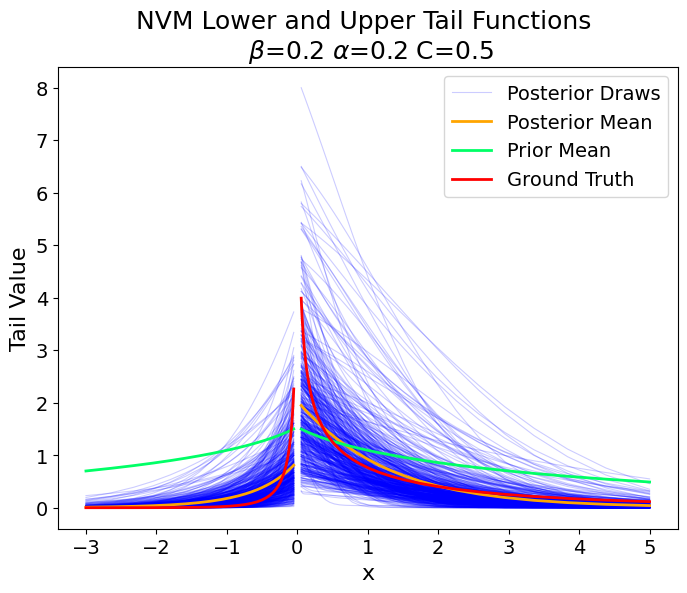

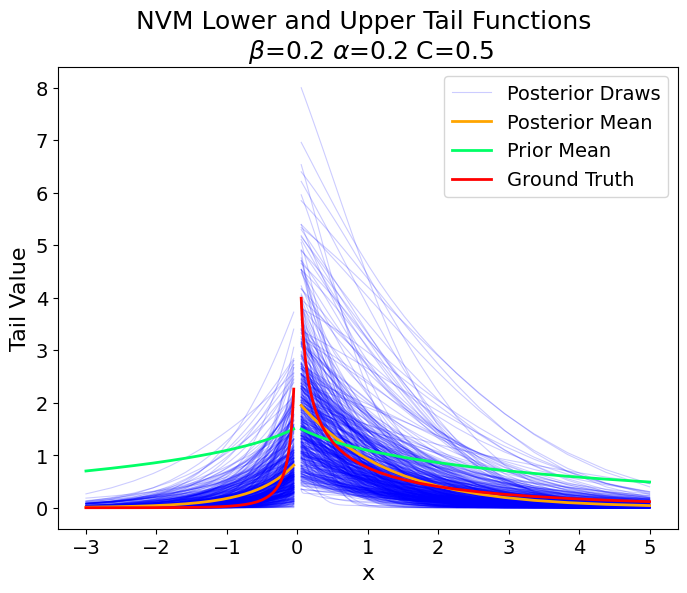

0.6225645163152814
(200001,)
(200001,)


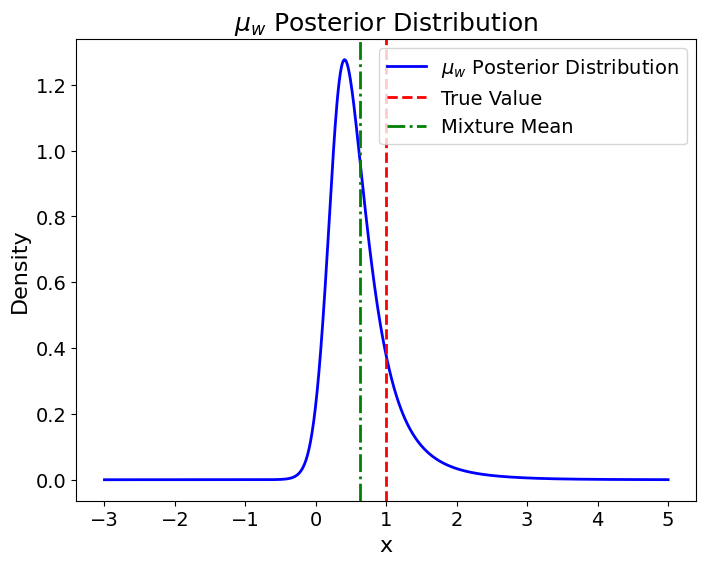

In [1]:
## Showing instead the realizations than the confidence intervals


 


factor = 1
# Comparison with the Priors
import numpy as np
from scipy.linalg import expm #This is the automatic matrix expnent solver
import math
import seaborn as sns
from scipy.special import logsumexp
from numba import jit
import matplotlib.pyplot as plt
from tqdm import tqdm
from posteriors import*
from Common_Tools import*
from Levy_Generators import*
from Levy_State_Space import*
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation, PillowWriter
from mcmc_sampler import*
from ground_truths import*
from mcmc_sampler_sigmaw2_conditional import *



num_samples_in_plot = 500
plt.rcParams.update({
    "figure.figsize": (8, 6),  # overall figure size
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})
#Load the observation dataset to just get the sigmaw2 value
data = np.load("TS_driven_NVM.npz")
sigmaw = data["sigmaw"]
sigmaw2 = sigmaw ** 2
beta = data["beta"]
alpha = data["alpha"]
C = data["C"]
muw = data["muw"]
T = data["T"]
sim_rate = data["sim_rate"]


#Quantile selection for the visualization
lower_percentage = 0.15
upper_percentage = 99.85

additional_burn_in = 0


#Load the experimental results stored for the samples
data = np.load("langevin_ts_sigmaw2_conditional.npz")
sample_measures = data["sample_measures"][additional_burn_in:]
sample_rates = data["sample_rates"][additional_burn_in:]
sample_x_means = data["sample_smoothed_means"][additional_burn_in:]
sample_x_covariances = data["sample_smoothed_covariances"][additional_burn_in:]


#Define the prior
rate_alpha_prior = 3 #Gamma base distirbution for the Dirichlet process prior
rate_beta_prior = 1
#dir_alpha = 2 #Can be understood as 10 observations from the base Gamma distribution
dir_K = 1000
#DP hyper-parameter prior or initialization definition
initial_dir_alpha = 10.0
initial_base_gamma_a = 1
initial_base_gamma_b= 2

dir_alpha_a = 1.0
dir_alpha_b = 3
#Normal(0,1) has been used for all the muw priors
muw_mean = 0
muw_variance = 10
#Subordinator Prior Measures for Visualization
prior_sample_measures,prior_sample_rates = draw_IGSDP_Prior_Measures(rate_alpha_prior,rate_beta_prior,initial_base_gamma_a,1/initial_base_gamma_b,dir_alpha_a,1/dir_alpha_b,dir_K,num_samples=1000)





#The Posterior Analysis Session
overall_rates_list = []
overall_positions_list = []
NVM_conditional_lower_tails = []
NVM_conditional_upper_tails = []
real_posterior_NVM_conditional_lower_tails = []
real_posterior_NVM_conditional_upper_tails = []

overall_NVM_discrete_rates = []
overall_NVM_discrete_positions = []
#Define the posterior analysis axis
epsilon = 1e-5 #The minimum valku for the x axis of the upper tail function. This cannot go to 0 for stability reason
x_axis = np.logspace(np.log10(epsilon),np.log10(5),1000) #Change the resolution parameter here to change the bin density
# Combine the negative and positive parts to form the nvm_axis
nvm_positive_axis = np.logspace(np.log10(epsilon),np.log10(5),100)
nvm_negative_axis =np.logspace(np.log10(epsilon),np.log10(3),100)
nvm_axis = np.concatenate([-nvm_negative_axis[::-1], nvm_positive_axis])
sample_upper_tail_measures = []

for i in tqdm(range(len(sample_measures)),desc="Posterior Analysis"):#Iterating over the samples in each iteration
    sample_rate = sample_rates[i]
    sample_measure = sample_measures[i]  # 2 x K
    #jump_dist_entropies.append(compute_entropy(sample_measure[0, :]))
    #probabilities = sample_measure[0,:]

    sample_measure[0, :] = sample_measure[0, :] * sample_rate  # K-dimensional array. Combining the rate and jump size distributioin into the Levy density
    sample_measures[i] = sample_measure
    #Then extract the information from the L\'evy density
    rates = sample_measure[0, :]
    positions = sample_measure[1, :]
    #Compute and store the upper tail measure function values on the x axis defined
    sample_upper_tail_measure = DP_upper_tail_projection(positions,rates,x_axis)
    sample_upper_tail_measures.append(sample_upper_tail_measure)
    # Collect arrays in lists
    overall_rates_list.append(rates)
    overall_positions_list.append(positions)
    #Posterior Analysis of the samples
    x_mean_sample_series = sample_x_means[i] #The mean series inferred by the Kalman filter 
    x_covariance_sample_series = sample_x_covariances[i]#The covariance series inferred by the Kalman filter
    muw_posterior_mean = x_mean_sample_series[-1,-1,0]
    muw_posterior_variance = x_covariance_sample_series[-1,-1,-1]#Note that this is the marginalized covariance wrt \sigma_w^2 but not the exact covariance
    #NVM_ground_truth_conditional,NVM_ground_truth_conditional_discrete_component = NVM_ground_truth_measure_with_ineffective_components(rates, positions, nvm_axis, muw, sigmaw)#Computed using the mixture of Gaussian with exact NVM parameters
    #NVM_density_conditional,NVM_density_conditional_discrete_component = NVM_measure_inference_with_ineffective_components(rates, positions,nvm_axis, muw_posterior_mean,muw_posterior_variance, alphaw_post,betaw_post)#Computed using the mixture of student-t
    lower_tail_conditional,upper_tail_conditional = NVM_measure_tail_functions_conditional_on_sigmaw2(rates, positions, nvm_axis, muw_posterior_mean, muw_posterior_variance, sigmaw2)#The mean estimates
    real_posterior_lower_tail_conditional,real_posterior_upper_tail_conditional,real_posterior_muw_sample = NVM_measure_tail_functions_sampled_on_sigmaw2(rates, positions, nvm_axis, muw_posterior_mean, muw_posterior_variance, sigmaw2)#Inference for the entire posterior distribution but not just the mean
    #Storing the inference results for the densities and/or the tails
    #NVM_conditional_densities.append(NVM_density_conditional)
    NVM_conditional_lower_tails.append(lower_tail_conditional)
    NVM_conditional_upper_tails.append(upper_tail_conditional)
    real_posterior_NVM_conditional_lower_tails.append(real_posterior_lower_tail_conditional)
    real_posterior_NVM_conditional_upper_tails.append(real_posterior_upper_tail_conditional)



prior_sample_upper_tail_measures = []
prior_overall_rates_list = []
prior_overall_positions_list = []
prior_NVM_conditional_lower_tails = []
prior_NVM_conditional_upper_tails = []
for i in tqdm(range(len(prior_sample_measures)),desc="Making Prior Visualization"):
    prior_sample_rate = prior_sample_rates[i]
    prior_sample_measure = prior_sample_measures[i]  # 2 x K
    #jump_dist_entropies.append(compute_entropy(sample_measure[0, :]))
    #probabilities = sample_measure[0,:]

    prior_sample_measure[0, :] = prior_sample_measure[0, :] * prior_sample_rate  # K-dimensional array. Combining the rate and jump size distributioin into the Levy density
    prior_sample_measures[i] = prior_sample_measure
    #Then extract the information from the L\'evy density
    prior_rates = prior_sample_measure[0, :]
    prior_positions = prior_sample_measure[1, :]
    #Compute and store the upper tail measure function values on the x axis defined
    prior_sample_upper_tail_measure = DP_upper_tail_projection(prior_positions,prior_rates,x_axis)
    prior_sample_upper_tail_measures.append(prior_sample_upper_tail_measure)
    # Collect arrays in lists
    prior_overall_rates_list.append(prior_rates)
    prior_overall_positions_list.append(prior_positions)
    
    prior_lower_tail_conditional,prior_upper_tail_conditional = NVM_measure_tail_functions_conditional_on_sigmaw2(prior_rates, prior_positions, nvm_axis, muw_mean, muw_variance, sigmaw2)

    #Storing the inference results for the densities and/or the tails
    #NVM_conditional_densities.append(NVM_density_conditional)
    prior_NVM_conditional_lower_tails.append(prior_lower_tail_conditional)
    prior_NVM_conditional_upper_tails.append(prior_upper_tail_conditional)

#Subordinator Procesing
rates = np.concatenate(overall_rates_list)
positions = np.concatenate(overall_positions_list)
#Divide the concatenate rates by the total number of samples to find the marginalized posterior DP measure mean
mean_weights = rates/(len(sample_measures))

prior_rates = np.concatenate(prior_overall_rates_list)
prior_positions = np.concatenate(prior_overall_positions_list)
#Divide the concatenate rates by the total number of samples to find the marginalized posterior DP measure mean
prior_mean_weights = prior_rates/(len(prior_sample_measures))

posterior_mean_upper_tail_values = DP_upper_tail_projection(positions,mean_weights,x_axis)
prior_mean_upper_tail_values = DP_upper_tail_projection(prior_positions,prior_mean_weights,x_axis)
ground_truth_upper_tail_values = upper_tail_ts_measure(alpha, beta*factor, C/(factor**alpha),x_axis)
# Stack the samples into a 2D array for easier quantile computation
ts_sample_array = np.vstack(sample_upper_tail_measures)

# Compute the quantiles (e.g., 2.5% and 97.5% for 95% CI)
ts_lower_quantile = np.percentile(ts_sample_array, lower_percentage, axis=0)
ts_upper_quantile = np.percentile(ts_sample_array, upper_percentage, axis=0)
prior_ts_sample_array = np.vstack(prior_sample_upper_tail_measures)
# Compute the quantiles (e.g., 2.5% and 97.5% for 95% CI)
prior_ts_lower_quantile = np.percentile(prior_ts_sample_array, lower_percentage, axis=0)
prior_ts_upper_quantile = np.percentile(prior_ts_sample_array, upper_percentage, axis=0)




#NVM Processing
NVM_upper_tail_array = np.vstack(NVM_conditional_upper_tails)
NVM_lower_tail_array = np.vstack(NVM_conditional_lower_tails)
real_posterior_NVM_upper_tail_array = np.vstack(real_posterior_NVM_conditional_upper_tails)
real_posterior_NVM_lower_tail_array = np.vstack(real_posterior_NVM_conditional_lower_tails)
prior_NVM_upper_tail_array = np.vstack(prior_NVM_conditional_upper_tails)
prior_NVM_lower_tail_array = np.vstack(prior_NVM_conditional_lower_tails)

    # Compute the average density or tail
#NVM_density_inferred= np.mean(NVM_densities_array, axis=0)  # Shape: (len(x_axis),)
#Quantile Computation for the NVM Tails
nvm_upper_tail_lower_quantile = np.percentile(NVM_upper_tail_array, lower_percentage, axis=0)
nvm_upper_tail_upper_quantile = np.percentile(NVM_upper_tail_array, upper_percentage, axis=0)
nvm_lower_tail_lower_quantile = np.percentile(NVM_lower_tail_array, lower_percentage, axis=0)
nvm_lower_tail_upper_quantile = np.percentile(NVM_lower_tail_array, upper_percentage, axis=0)

real_posterior_nvm_upper_tail_lower_quantile = np.percentile(real_posterior_NVM_upper_tail_array, lower_percentage, axis=0)
real_posterior_nvm_upper_tail_upper_quantile = np.percentile(real_posterior_NVM_upper_tail_array, upper_percentage, axis=0)
real_posterior_nvm_lower_tail_lower_quantile = np.percentile(real_posterior_NVM_lower_tail_array, lower_percentage, axis=0)
real_posterior_nvm_lower_tail_upper_quantile = np.percentile(real_posterior_NVM_lower_tail_array, upper_percentage, axis=0)


prior_nvm_upper_tail_lower_quantile = np.percentile(prior_NVM_upper_tail_array, lower_percentage, axis=0)
prior_nvm_upper_tail_upper_quantile = np.percentile(prior_NVM_upper_tail_array, upper_percentage, axis=0)
prior_nvm_lower_tail_lower_quantile = np.percentile(prior_NVM_lower_tail_array, lower_percentage, axis=0)
prior_nvm_lower_tail_upper_quantile = np.percentile(prior_NVM_lower_tail_array, upper_percentage, axis=0)


NVM_upper_tail_inferred = np.mean(NVM_upper_tail_array,axis=0)
NVM_lower_tail_inferred = np.mean(NVM_lower_tail_array,axis=0)
real_posterior_NVM_upper_tail_inferred = np.mean(real_posterior_NVM_upper_tail_array,axis=0)
real_posterior_NVM_lower_tail_inferred = np.mean(real_posterior_NVM_lower_tail_array,axis=0)
prior_NVM_upper_tail_inferred = np.mean(prior_NVM_upper_tail_array,axis=0)
prior_NVM_lower_tail_inferred = np.mean(prior_NVM_lower_tail_array,axis=0)


#NVM ground truth tails generation
gt_sub_jump_sizes,gt_jump_times = tempered_stable_process_jumps((beta*factor,alpha,C/(factor**alpha)),T*5000,sim_rate)#Generate a bunch of jump sizes and times for computing the ground truth
NVM_lower_tail_ground_truth,NVM_upper_tail_ground_truth = NVM_ground_truth_tail_functions(nvm_axis,gt_sub_jump_sizes[0,:],muw*factor,sigmaw*np.sqrt(factor),alpha,beta*factor,C/(factor**alpha),epsilon*1e-2/factor)#The truncated threshold for the approximation needs also be adjusted for jump size scaling.
negative_axis = nvm_axis[nvm_axis < 0]
positive_axis = nvm_axis[nvm_axis > 0]



original_x_axis = x_axis
original_ground_truth_upper_tail_values = ground_truth_upper_tail_values
original_posterior_mean_upper_tail_values = posterior_mean_upper_tail_values
original_ts_lower_quantile = ts_lower_quantile
original_ts_upper_quantile = ts_upper_quantile


#Generating the thinned sample measures for visualization

thinned_prior_ts_array = thin_uniform(prior_ts_sample_array,num_samples_in_plot)
thinned_posterior_ts_array = thin_uniform(ts_sample_array,num_samples_in_plot)
thinned_prior_nvm_upper_tail_array = thin_uniform(prior_NVM_upper_tail_array,num_samples_in_plot)
thinned_posterior_nvm_upper_tail_array = thin_uniform(NVM_upper_tail_array,num_samples_in_plot)
thinned_real_posterior_nvm_upper_tail_array = thin_uniform(real_posterior_NVM_upper_tail_array,num_samples_in_plot)
thinned_prior_nvm_lower_tail_array = thin_uniform(prior_NVM_lower_tail_array,num_samples_in_plot)
thinned_posterior_nvm_lower_tail_array = thin_uniform(NVM_lower_tail_array,num_samples_in_plot)
thinned_real_posterior_nvm_lower_tail_array = thin_uniform(real_posterior_NVM_lower_tail_array,num_samples_in_plot)





#Plotting Sessions
#Plotting the subordinator upper tail functions
#Compute the upper tail measure for the DP posterior mean measure and also the ground truth
#Compute the quantiles given the x_axis

truncation_threshold = 0.1
mask = x_axis >= truncation_threshold
x_axis = original_x_axis[mask]
ground_truth_upper_tail_values = original_ground_truth_upper_tail_values[mask]
posterior_mean_upper_tail_values = original_posterior_mean_upper_tail_values[mask]
prior_mean_upper_tail_values = prior_mean_upper_tail_values[mask]
ts_lower_quantile = original_ts_lower_quantile[mask]
ts_upper_quantile = original_ts_upper_quantile[mask]
prior_ts_lower_quantile = prior_ts_lower_quantile[mask]
prior_ts_upper_quantile = prior_ts_upper_quantile[mask]

thinned_prior_ts_array = thinned_prior_ts_array[:,mask]
thinned_posterior_ts_array = thinned_posterior_ts_array[:,mask]


original_negative_axis = negative_axis
original_nvm_lower_tail_lower_quantile = nvm_lower_tail_lower_quantile
original_nvm_lower_tail_upper_quantile = nvm_lower_tail_upper_quantile
original_NVM_lower_tail_inferred = NVM_lower_tail_inferred
original_NVM_lower_tail_ground_truth = NVM_lower_tail_ground_truth

original_positive_axis = positive_axis
original_nvm_upper_tail_lower_quantile = nvm_upper_tail_lower_quantile
original_nvm_upper_tail_upper_quantile = nvm_upper_tail_upper_quantile
original_NVM_upper_tail_inferred = NVM_upper_tail_inferred
original_NVM_upper_tail_ground_truth = NVM_upper_tail_ground_truth

original_real_posterior_nvm_lower_tail_lower_quantile = real_posterior_nvm_lower_tail_lower_quantile
original_real_posterior_nvm_lower_tail_upper_quantile = real_posterior_nvm_lower_tail_upper_quantile
original_real_posterior_NVM_lower_tail_inferred = real_posterior_NVM_lower_tail_inferred

original_real_posterior_nvm_upper_tail_lower_quantile = real_posterior_nvm_upper_tail_lower_quantile
original_real_posterior_nvm_upper_tail_upper_quantile = real_posterior_nvm_upper_tail_upper_quantile
original_real_posterior_NVM_upper_tail_inferred = real_posterior_NVM_upper_tail_inferred


#Plotting the NVM Tail Densities Inferred against the ground truth
# Split nvm_axis into negative and positive halves
truncation_threshold = 0.05
negative_axis = nvm_axis[nvm_axis < -0]
positive_axis = nvm_axis[nvm_axis > 0]
negative_axis_mask = negative_axis<-truncation_threshold
positive_axis_mask = positive_axis>truncation_threshold

negative_axis = original_negative_axis[negative_axis_mask]
nvm_lower_tail_lower_quantile = original_nvm_lower_tail_lower_quantile[negative_axis_mask]
real_posterior_nvm_lower_tail_lower_quantile = original_real_posterior_nvm_lower_tail_lower_quantile[negative_axis_mask]
prior_nvm_lower_tail_lower_quantile = prior_nvm_lower_tail_lower_quantile[negative_axis_mask]
nvm_lower_tail_upper_quantile = original_nvm_lower_tail_upper_quantile[negative_axis_mask]
real_posterior_nvm_lower_tail_upper_quantile = original_real_posterior_nvm_lower_tail_upper_quantile[negative_axis_mask]
prior_nvm_lower_tail_upper_quantile = prior_nvm_lower_tail_upper_quantile[negative_axis_mask]
NVM_lower_tail_inferred =  original_NVM_lower_tail_inferred[negative_axis_mask]
real_posterior_NVM_lower_tail_inferred = original_real_posterior_NVM_lower_tail_inferred[negative_axis_mask]
prior_NVM_lower_tail_inferred = prior_NVM_lower_tail_inferred[negative_axis_mask]
NVM_lower_tail_ground_truth = original_NVM_lower_tail_ground_truth[negative_axis_mask]


positive_axis = original_positive_axis[positive_axis_mask]
nvm_upper_tail_lower_quantile = original_nvm_upper_tail_lower_quantile[positive_axis_mask]
nvm_upper_tail_upper_quantile = original_nvm_upper_tail_upper_quantile[positive_axis_mask]
NVM_upper_tail_inferred = original_NVM_upper_tail_inferred[positive_axis_mask]
real_posterior_nvm_upper_tail_lower_quantile = original_real_posterior_nvm_upper_tail_lower_quantile[positive_axis_mask]
real_posterior_nvm_upper_tail_upper_quantile = original_real_posterior_nvm_upper_tail_upper_quantile[positive_axis_mask]
real_posterior_NVM_upper_tail_inferred = original_real_posterior_NVM_upper_tail_inferred[positive_axis_mask]
prior_nvm_upper_tail_lower_quantile = prior_nvm_upper_tail_lower_quantile[positive_axis_mask]
prior_nvm_upper_tail_upper_quantile = prior_nvm_upper_tail_upper_quantile[positive_axis_mask]
prior_NVM_upper_tail_inferred = prior_NVM_upper_tail_inferred[positive_axis_mask]
NVM_upper_tail_ground_truth = original_NVM_upper_tail_ground_truth[positive_axis_mask]


thinned_prior_nvm_upper_tail_array = thinned_prior_nvm_upper_tail_array[:,positive_axis_mask]
thinned_posterior_nvm_upper_tail_array = thinned_posterior_nvm_upper_tail_array[:,positive_axis_mask]
thinned_real_posterior_nvm_upper_tail_array = thinned_real_posterior_nvm_upper_tail_array[:,positive_axis_mask]
thinned_prior_nvm_lower_tail_array = thinned_prior_nvm_lower_tail_array[:,negative_axis_mask]
thinned_posterior_nvm_lower_tail_array = thinned_posterior_nvm_lower_tail_array[:,negative_axis_mask]
thinned_real_posterior_nvm_lower_tail_array = thinned_real_posterior_nvm_lower_tail_array[:,negative_axis_mask]











#Visualization Session


#NVM Posterior Mean Plot
plt.figure(figsize=(8, 6))
# Plot lower tail
for i in range(num_samples_in_plot):
    if i == 0:
         plt.plot(
            negative_axis, 
            thinned_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8,label="Posterior Draws"
        )
    else:
        plt.plot(
            negative_axis, 
            thinned_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8
        )

plt.plot(
    negative_axis, 
    NVM_lower_tail_inferred, 
    color="orange", linewidth=2, label="Posterior Mean"
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         negative_axis, 
#         thinned_prior_nvm_lower_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    negative_axis, 
    prior_NVM_lower_tail_inferred, 
    color="#00FF66", linewidth=2, label="Prior Mean"
)
plt.plot(
    negative_axis, 
    NVM_lower_tail_ground_truth, 
    color="red", linewidth=2, label="Ground Truth"
)

# Plot upper tail
for i in range(num_samples_in_plot):
    plt.plot(
        positive_axis, 
        thinned_posterior_nvm_upper_tail_array[i], 
        color="blue", alpha=0.2, linewidth=0.8
    )
plt.plot(
    positive_axis, 
    NVM_upper_tail_inferred, 
    color="orange", linewidth=2
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         positive_axis, 
#         thinned_prior_nvm_upper_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    positive_axis, 
    prior_NVM_upper_tail_inferred, 
    color="#00FF66", linewidth=2
)
plt.plot(
    positive_axis, 
    NVM_upper_tail_ground_truth, 
    color="red", linewidth=2
)
# Add labels and legend
#plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at y=0
#plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at x=0
plt.title(f"NVM Lower and Upper Tail Functions \n $\\beta$={np.round(beta,2)} $\\alpha$={np.round(alpha,2)} C={np.round(C,2)}")
plt.xlabel("x")
plt.ylabel("Tail Value")
#plt.xscale("symlog",linthresh=epsilon*100)
#plt.yscale("log")
plt.legend()
# Show plot
plt.show()




#NVM Real Posterior Inference Plot
plt.figure(figsize=(8, 6))
# Plot lower tail
for i in range(num_samples_in_plot):
    if i == 0:
         plt.plot(
            negative_axis, 
            thinned_real_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8,label="Posterior Draws"
        )
    else:
        plt.plot(
            negative_axis, 
            thinned_real_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8
        )

plt.plot(
    negative_axis, 
    real_posterior_NVM_lower_tail_inferred, 
    color="orange", linewidth=2, label="Posterior Mean"
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         negative_axis, 
#         thinned_prior_nvm_lower_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    negative_axis, 
    prior_NVM_lower_tail_inferred, 
    color="#00FF66", linewidth=2, label="Prior Mean"
)
plt.plot(
    negative_axis, 
    NVM_lower_tail_ground_truth, 
    color="red", linewidth=2, label="Ground Truth"
)

# Plot upper tail
for i in range(num_samples_in_plot):
    plt.plot(
        positive_axis, 
        thinned_real_posterior_nvm_upper_tail_array[i], 
        color="blue", alpha=0.2, linewidth=0.8
    )
plt.plot(
    positive_axis, 
    real_posterior_NVM_upper_tail_inferred, 
    color="orange", linewidth=2
)
# for i in range(num_samples_in_plot):
#     plt.plot(
#         positive_axis, 
#         thinned_prior_nvm_upper_tail_array[i], 
#         color="green", alpha=0.2, linewidth=0.8
#     )
plt.plot(
    positive_axis, 
    prior_NVM_upper_tail_inferred, 
    color="#00FF66", linewidth=2
)
plt.plot(
    positive_axis, 
    NVM_upper_tail_ground_truth, 
    color="red", linewidth=2
)
# Add labels and legend
#plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at y=0
#plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at x=0
plt.title(f"NVM Lower and Upper Tail Functions \n $\\beta$={np.round(beta,2)} $\\alpha$={np.round(alpha,2)} C={np.round(C,2)}")
plt.xlabel("x")
plt.ylabel("Tail Value")
#plt.xscale("symlog",linthresh=epsilon*100)
#plt.yscale("log")
plt.legend()
# Show plot
plt.show()




#Plotting muw again with the adjusted ground truth

sample_muw_means = sample_x_means[:,-1,-1,-1]
sample_muw_covariances = sample_x_covariances[:,-1,-1,-1]
print(np.mean(sample_muw_means))
print(np.shape(sample_muw_means))
print(np.shape(sample_muw_covariances))


# Define the range for plotting
x = np.linspace(-3, 5, 1000)
weights = np.ones(len(sample_muw_covariances)) / len(sample_muw_covariances)
plot_mixture_of_gaussians(sample_muw_means,sample_muw_covariances,weights,x,muw,f"$\\mu_w$ Posterior Distribution",show_mixture_mean=True)





## Bimodal Subordinator driven NVM in Langevin Model

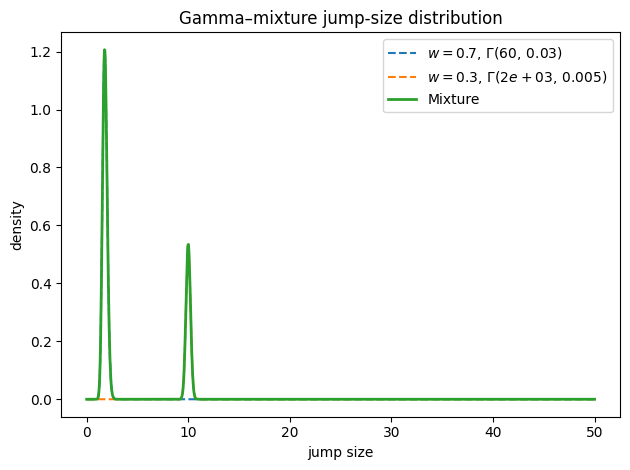

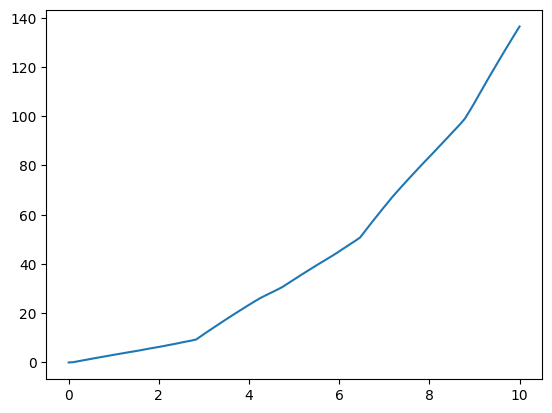

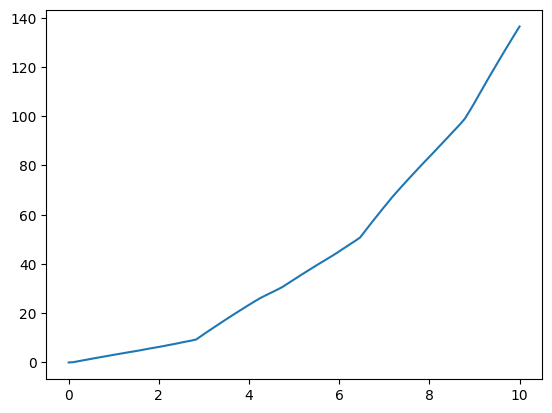

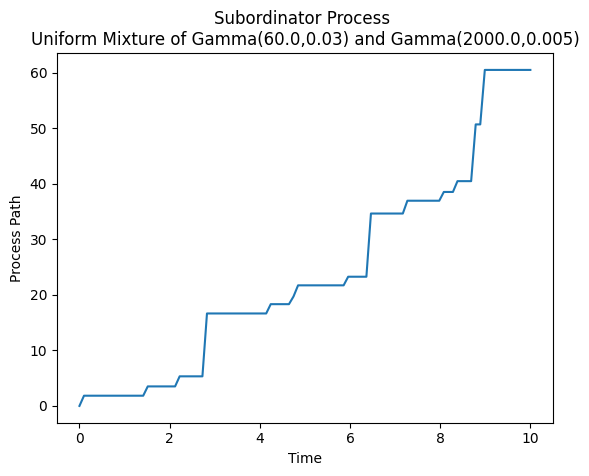

In [1]:
# ==== Deterministic + Stable RNG setup ====
import os
import random
import numpy as np
from scipy.linalg import expm #This is the automatic matrix expnent solver
import math
import seaborn as sns
from scipy.special import logsumexp
from numba import jit
import matplotlib.pyplot as plt
from tqdm import tqdm
from posteriors import*
from Common_Tools import*
from Levy_Generators import*
from Levy_State_Space import*
from mcmc_sampler import*
from ground_truths import*
from mcmc_sampler_sigmaw2_conditional import *
from bimodal_experiments_sampler import *


shapes = [60,2000]
scales = [0.03,0.005]
weights = [0.7,0.3]
plot_gamma_mixture(shapes,scales,weights)
T = 10.0
time_axis = np.linspace(0,T,int(T)*10)
rate = 2.0

# ===== Load simulation data =====
data = np.load("bimodal_driven_NVM.npz")

shapes = data["shapes"]
scales = data["scales"]
weights = data["weights"]
T = float(data["T"])
time_axis = data["time_axis"]
rate = float(data["rate"])

sub_jump_sizes = data["sub_jump_sizes"]
jump_times = data["jump_times"]
process_path = data["process_path"]

muw = float(data["muw"]) #1.0
sigmaw = float(data["sigmaw"]) #1.0
sigmaw2 = float(data["sigmaw2"])
nvm_jump_sizes = data["nvm_jump_sizes"]

theta = float(data["theta"])
langevin_path = data["langevin_path"]
true_x = data["true_x"]
true_x_dot = data["true_x_dot"]

observation_noise_level = 0.01
sigmav2 = observation_noise_level**2
full_observations = langevin_observations(langevin_path,(observation_noise_level**2)*np.identity(2))
observations = np.zeros((1,np.shape(full_observations)[1]))
observations[0,:] = full_observations[0,:]
plt.figure()
plt.plot(time_axis,observations[0,:])
plt.show()

plt.figure()
plt.plot(time_axis,observations[0,:])
plt.show()
plt.figure()
plt.plot(time_axis,process_path[0,:])
plt.xlabel("Time")
plt.ylabel("Process Path")
plt.title(f"Subordinator Process \nUniform Mixture of Gamma({shapes[0]},{scales[0]}) and Gamma({shapes[1]},{scales[1]})")
plt.show()

In [ ]:
#Extended MCMC Algorithm with Hyper-parameter Sampling
#Inference Parameters
burn_in = 20000
num_iter = 80000  
block_width = 1
overlapping_width = 0
#Make a guess for sigmaw2
sigmaw2 = 1.0

#shape rate convention here
rate_alpha_prior = 3 #Gamma base distirbution for the Dirichlet process prior
rate_beta_prior = 1
#dir_alpha = 2 #Can be understood as 10 observations from the base Gamma distribution
dir_K = 1000
#DP hyper-parameter prior or initialization definition. Note that the Gamma base to DP here follows the shape-scale convention
initial_dir_alpha = 0.5
initial_base_gamma_a = 1
initial_base_gamma_b=3 #scale, not rate

#Shape-scale convention here.
dir_alpha_a = 0.5
dir_alpha_b = 0.5

base_gamma_a_mean = initial_base_gamma_a
base_gamma_a_std = 1000.0
base_gamma_b_mean = initial_base_gamma_b
base_gamma_b_std = 1000.0
base_gamma_a_step_size = 0.0
base_gamma_b_step_size = 0.0

#Defining the theta prior and the GRW proposal step size
theta_prior = theta * 1.0
theta_step_size = observation_noise_level * 0.1 #This is the factor applied to the standard deviation. Square it to apply it to the variance.

#Define the muw prior
prior_muw_mean = 0
prior_muw_variance = 10

#Random Initialization from the bimodal set
initial_jump_sizes,initial_jump_times = compound_poisson_gamma_mixture(rate,shapes,scales,weights,T)
grouped_jump_sizes,grouped_jump_times = group_jumps(initial_jump_sizes,initial_jump_times,time_axis)
sample_measures,sample_rates,sample_paths,sample_thetas,overall_theta_acceptance_probability,sample_x_means,sample_x_covariances,dir_alphas,base_gamma_as,base_gamma_bs = langevin_lm_theta_inference_all_DP_alpha_inferred_Gamma_base_Gaussian_update_conditional_sigmaw2(num_iter,block_width,overlapping_width,observations,time_axis,initial_jump_sizes,initial_jump_times,sigmav2,rate_alpha_prior,rate_beta_prior,dir_K,dir_alpha_a,dir_alpha_b,base_gamma_a_mean,base_gamma_a_std,base_gamma_b_mean,base_gamma_b_std,sigmaw2,theta_prior,theta_step_size,base_gamma_a_step_size,base_gamma_b_step_size,dir_alpha=initial_dir_alpha,base_gamma_a=initial_base_gamma_a,base_gamma_b=initial_base_gamma_b,muw_prior_mean=prior_muw_mean,muw_prior_variance=prior_muw_variance)

#Discard the burn-in
sample_measures = sample_measures[burn_in:]
sample_rates = sample_rates[burn_in:]
sample_paths = sample_paths[burn_in:]
sample_thetas = sample_thetas[burn_in:]
sample_x_means = sample_x_means[burn_in:]
sample_x_covariances = sample_x_covariances[burn_in:]


np.savez(
    "langevin_bimodal_sigmaw2_conditional.npz",
    sample_measures=sample_measures,
    sample_rates=sample_rates,
    sample_paths=sample_paths,
    sample_thetas=sample_thetas,
    sample_x_means=sample_x_means,
    sample_x_covariances=sample_x_covariances,
    overall_theta_acceptance_probability = overall_theta_acceptance_probability,
    dir_alphas = dir_alphas
    
)


#The Posterior Analysis Session
overall_rates_list = []
overall_positions_list = []
#NVM_ground_truth_conditional_densities = []
#overall_NVM_ground_truth_discrete_rates = []
#overall_NVM_ground_truth_discrete_positions = []
#NVM_conditional_densities = []
NVM_conditional_lower_tails = []
NVM_conditional_upper_tails = []
overall_NVM_discrete_rates = []
overall_NVM_discrete_positions = []
#Define the posterior analysis axis
epsilon = 1e-5 #The minimum valku for the x axis of the upper tail function. This cannot go to 0 for stability reason
x_axis = np.linspace(np.log10(epsilon),np.log10(5),1000) #Change the resolution parameter here to change the bin density
# Combine the negative and positive parts to form the nvm_axis
nvm_positive_axis = np.logspace(np.log10(epsilon),np.log10(5),100)
nvm_negative_axis =np.logspace(np.log10(epsilon),np.log10(3),100)
nvm_axis = np.concatenate([-nvm_negative_axis[::-1], nvm_positive_axis])
sample_upper_tail_measures = []
#effective_component_numbers = []

#jump_dist_entropies = []
# Averaging the sample measures
# Combining the rate and jump size distribution into the Levy measure

for i in tqdm(range(len(sample_measures)),desc="Posterior Analysis"):#Iterating over the samples in each iteration
    sample_rate = sample_rates[i]
    sample_measure = sample_measures[i]  # 2 x K
    #jump_dist_entropies.append(compute_entropy(sample_measure[0, :]))
    #probabilities = sample_measure[0,:]

    sample_measure[0, :] = sample_measure[0, :] * sample_rate  # K-dimensional array. Combining the rate and jump size distributioin into the Levy density
    sample_measures[i] = sample_measure
    #Then extract the information from the L\'evy density
    rates = sample_measure[0, :]
    positions = sample_measure[1, :]
    #Compute and store the upper tail measure function values on the x axis defined
    sample_upper_tail_measure = DP_upper_tail_projection(positions,rates,x_axis)
    sample_upper_tail_measures.append(sample_upper_tail_measure)
    # Collect arrays in lists
    overall_rates_list.append(rates)
    overall_positions_list.append(positions)
    #Posterior Analysis of the samples
    x_mean_sample_series = sample_x_means[i] #The mean series inferred by the Kalman filter 
    x_covariance_sample_series = sample_x_covariances[i]#The covariance series inferred by the Kalman filter
    muw_posterior_mean = x_mean_sample_series[-1,-1,0]
    muw_posterior_variance = x_covariance_sample_series[-1,-1,-1]#Note that this is the marginalized covariance wrt \sigma_w^2 but not the exact covariance
    #NVM_ground_truth_conditional,NVM_ground_truth_conditional_discrete_component = NVM_ground_truth_measure_with_ineffective_components(rates, positions, nvm_axis, muw, sigmaw)#Computed using the mixture of Gaussian with exact NVM parameters
    #NVM_density_conditional,NVM_density_conditional_discrete_component = NVM_measure_inference_with_ineffective_components(rates, positions,nvm_axis, muw_posterior_mean,muw_posterior_variance, alphaw_post,betaw_post)#Computed using the mixture of student-t
    lower_tail_conditional,upper_tail_conditional = NVM_measure_tail_functions_conditional_on_sigmaw2(rates, positions, nvm_axis, muw_posterior_mean, muw_posterior_variance, sigmaw2)

    #Storing the inference results for the densities and/or the tails
    #NVM_conditional_densities.append(NVM_density_conditional)
    NVM_conditional_lower_tails.append(lower_tail_conditional)
    NVM_conditional_upper_tails.append(upper_tail_conditional)
    #NVM_ground_truth_conditional_densities.append(NVM_ground_truth_conditional)
    #overall_NVM_ground_truth_discrete_rates.append(NVM_ground_truth_conditional_discrete_component[0,:])
    #overall_NVM_ground_truth_discrete_positions.append(NVM_ground_truth_conditional_discrete_component[1,:])
    #overall_NVM_discrete_rates.append(NVM_density_conditional_discrete_component[0,:])
    #overall_NVM_discrete_positions.append(NVM_density_conditional_discrete_component[1,:])

#Plotting the hidden state inference
average_x_means,average_x_covariances = Gaussian_average(sample_x_means,sample_x_covariances)
std_devs = np.sqrt(np.diagonal(average_x_covariances, axis1=1, axis2=2))  # Shape: (100, 3)
states_names = ["x",f"$dx/dt$",f"\mu_w"]
true_state_values = [true_x,true_x_dot,muw*np.ones(len(time_axis))]
for state_idx in range(3):  # Loop over the 3 states
    plt.figure(figsize=(8, 6))
    state_name = states_names[state_idx]
    true_values = true_state_values[state_idx]
    means = average_x_means[:, state_idx, 0]  # Mean values for the current state

    stds = std_devs[:, state_idx]  # Standard deviations for the current state

    # Plot the mean values
    plt.plot(time_axis, means, label=f'{state_name} Mean', color='blue')

    if state_idx == 0:
        plt.plot(time_axis,observations[0,:],label = "Noisy Observations")

    # Plot the confidence intervals (3 standard deviations)
    plt.fill_between(
        time_axis,
        means - 3 * stds,
        means + 3 * stds,
        color='blue',
        alpha=0.2,
        label='3-STD CI'
    )
    plt.plot(time_axis,true_values,label=f"True {state_name}")
    plt.title(f'{state_name} Mean and Confidence Interval')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid()
    plt.show()




# Concatenate arrays outside of the loop for better performance
rates = np.concatenate(overall_rates_list)
positions = np.concatenate(overall_positions_list)
#Divide the concatenate rates by the total number of samples to find the marginalized posterior DP measure mean
mean_weights = rates/(num_iter+1) # The mean_weights and positions together form the posterior mean DP measure.


#Infer the NVM Density/tails, additional average needed to marginalize out the condition on the subordinator series
#NVM_densities_array = np.vstack(NVM_conditional_densities)  # Shape: (num_densities, len(x_axis))
NVM_upper_tail_array = np.vstack(NVM_conditional_upper_tails)
NVM_lower_tail_array = np.vstack(NVM_conditional_lower_tails)
    # Compute the average density or tail
#NVM_density_inferred= np.mean(NVM_densities_array, axis=0)  # Shape: (len(x_axis),)
#Quantile Computation for the NVM Tails
lower_percentage = 0.15
upper_percentage = 99.85
nvm_upper_tail_lower_quantile = np.percentile(NVM_upper_tail_array, lower_percentage, axis=0)
nvm_upper_tail_upper_quantile = np.percentile(NVM_upper_tail_array, upper_percentage, axis=0)
nvm_lower_tail_lower_quantile = np.percentile(NVM_lower_tail_array, lower_percentage, axis=0)
nvm_lower_tail_upper_quantile = np.percentile(NVM_lower_tail_array, upper_percentage, axis=0)

NVM_upper_tail_inferred = np.mean(NVM_upper_tail_array,axis=0)
NVM_lower_tail_inferred = np.mean(NVM_lower_tail_array,axis=0)




#Plotting Sessions
#Plotting the subordinator upper tail functions
#Compute the upper tail measure for the DP posterior mean measure and also the ground truth
posterior_mean_upper_tail_values = DP_upper_tail_projection(positions,mean_weights,x_axis)
#Compute the quantiles given the x_axis

    # Stack the samples into a 2D array for easier quantile computation
ts_sample_array = np.vstack(sample_upper_tail_measures)

# Compute the quantiles (e.g., 2.5% and 97.5% for 95% CI)
ts_lower_quantile = np.percentile(ts_sample_array, lower_percentage, axis=0)
ts_upper_quantile = np.percentile(ts_sample_array, upper_percentage, axis=0)

plt.figure(figsize=(8, 6))

# Plot the posterior mean
plt.plot(x_axis, posterior_mean_upper_tail_values, label="Posterior Mean", color="blue", linewidth=2)

# Plot the confidence interval
plt.fill_between(
    x_axis, ts_lower_quantile, ts_upper_quantile, color="blue", alpha=0.2, label=f"{round(upper_percentage-lower_percentage,4)}% CI"
)

# Add labels, legend, and title
plt.xlabel("x")
plt.ylabel("Upper Tail Values")
plt.title(f"Subordinator Upper Tail Function Inferred")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()




#Plotting the NVM Tail Densities Inferred against the ground truth
# Split nvm_axis into negative and positive halves
negative_axis = nvm_axis[nvm_axis < 0]
positive_axis = nvm_axis[nvm_axis > 0]
# Plot lower tail
plt.fill_between(
    negative_axis, 
    nvm_lower_tail_lower_quantile, 
    nvm_lower_tail_upper_quantile, 
    color="blue", alpha=0.2, label=f"Lower Tail {round(upper_percentage-lower_percentage,4)} CI"
)
plt.plot(
    negative_axis, 
    NVM_lower_tail_inferred, 
    color="blue", linestyle="--", linewidth=2, label="Lower Tail Inferred"
)


# Plot upper tail
plt.fill_between(
    positive_axis, 
    nvm_upper_tail_lower_quantile, 
    nvm_upper_tail_upper_quantile, 
    color="red", alpha=0.2, label=f"Upper Tail {round(upper_percentage-lower_percentage,4)} CI"
)
plt.plot(
    positive_axis, 
    NVM_upper_tail_inferred, 
    color="red", linestyle="--", linewidth=2, label="Upper Tail Inferred"
)

# Add labels and legend
#plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at y=0
#plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at x=0
plt.title(f"NVM Lower and Upper Tail Functions")
plt.xlabel("x")
#plt.ylabel("Tail Value")
plt.xscale("symlog",linthresh=epsilon*100)
plt.yscale("log")
plt.legend()
# Show plot
plt.show()




# Theta Sample Plot
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
sns.histplot(sample_thetas, kde=False, stat="density", linewidth=0) #Turn on and off the kernel density here. Prof Godsill doesn't like it so it is turned off here
plt.axvline(np.mean(sample_thetas), color='r', linestyle='--', label=f'Mean: {np.mean(sample_thetas):.2f}')
plt.axvline(np.percentile(sample_thetas, 0.15), color='g', linestyle=':', label='95% CI')
plt.axvline(np.percentile(sample_thetas, 99.85), color='g', linestyle=':')
plt.axvline(theta, color='blue', linestyle='-', label=f'True: {theta}')
plt.title(f'Posterior distribution of $\\theta$ \n Acceptance Probability: {overall_theta_acceptance_probability}')
plt.legend()
plt.show()
#Theta Trace Plot
plt.figure()
plt.plot(sample_thetas)
plt.title(f"$\\theta$ Trace")
plt.show()


max_lag = 5000
#Autocorrelation analysis of jump_dist_entropies, sample_rates, sample_thetas and sample_paths
#jump_dist_acf,jump_dist_iact = compute_acf_and_iact(jump_dist_entropies, max_lag)
#rate_acf,rate_iact = compute_acf_and_iact(sample_rates,max_lag)
theta_acf,theta_iact = compute_acf_and_iact(sample_thetas,max_lag)
#alternative_autocorr = acf(sample_thetas, nlags=max_lag, fft=True)
sample_paths = np.array(sample_paths)[:,0,:] #This converts the length N list with each element being (T,) array into an (N,T) matrix compatible with the ACF and IACT function
sample_path_acf,sample_path_iact = compute_functional_acf_and_act(sample_paths,time_axis, max_lag)
sample_upper_tail_measure_matrix = np.array(sample_upper_tail_measures)
upper_tail_measure_acf,upper_tail_measure_iact = compute_functional_acf_and_act(sample_upper_tail_measure_matrix,x_axis, max_lag)
acf_arrays = [upper_tail_measure_acf,theta_acf, sample_path_acf]
iact_values = [upper_tail_measure_iact,theta_iact, sample_path_iact]
labels = ["Upper Tail Function of Subordinator Measure",f"$\\theta$", "Subordinator Path"]
max_lag = len(theta_acf) - 1
plot_acf_arrays(acf_arrays, iact_values, labels, max_lag)


#dir_alphas,base_gamma_as,base_gamma_bs
plt.figure()
plt.plot(dir_alphas)
plt.title(f"$\\alpha$ Trace")
plt.show()

plt.figure()
plt.plot(base_gamma_as)
plt.title(f"Base Gamma a Trace")
plt.show()

plt.figure()
plt.plot(base_gamma_bs)
plt.title(f"Base Gamma b Trace")
plt.show()


<>:131: SyntaxWarning: invalid escape sequence '\m'
<>:131: SyntaxWarning: invalid escape sequence '\m'
/var/folders/my/1lmytx1n493d41xbk6p_vgkw0000gn/T/ipykernel_39634/2108468159.py:131: SyntaxWarning: invalid escape sequence '\m'
  states_names = ["x",f"$dx/dt$",f"\mu_w"]
Langevin System Inference Progress::   0%|          | 17/80000 [00:05<7:22:10,  3.01it/s]

Making Prior Visualization: 100%|██████████| 5000/5000 [00:09<00:00, 528.07it/s]


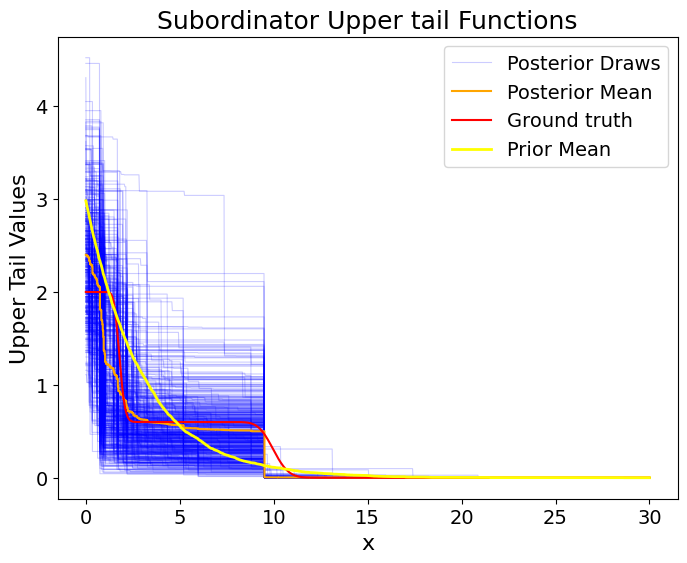

Posterior Analysis: 100%|██████████| 60001/60001 [01:38<00:00, 610.27it/s]


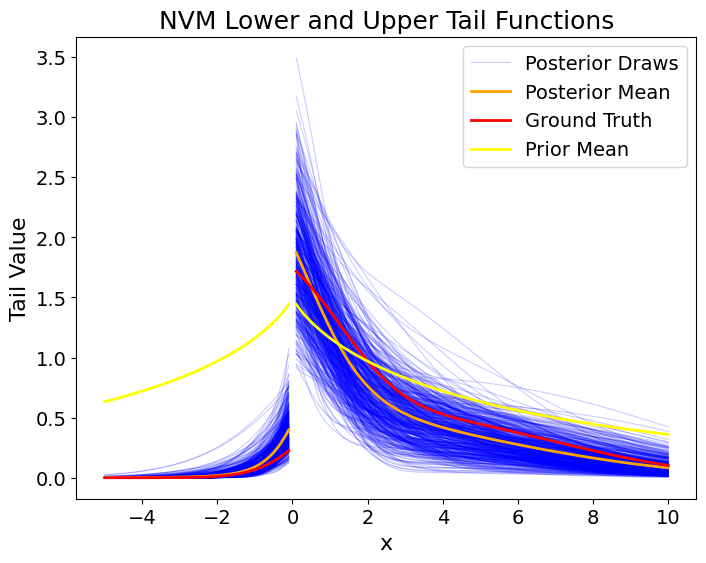

In [1]:
## Proper Prior Visualization with Confidence Bands but not Just the Mean

import numpy as np
from scipy.linalg import expm #This is the automatic matrix expnent solver
import math
import seaborn as sns
from scipy.special import logsumexp
from numba import jit
import matplotlib.pyplot as plt
from tqdm import tqdm
from posteriors import*
from Common_Tools import*
from Levy_Generators import*
from Levy_State_Space import*
from mcmc_sampler import*
from ground_truths import*
from mcmc_sampler_sigmaw2_conditional import *
from bimodal_experiments_sampler import *

plt.rcParams.update({
    "figure.figsize": (14, 6),  # overall figure size
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})


num_samples_in_plot = 500


#Define the gt nvm parameters
muw = 0.7
sigmaw2 = 1

#Prior Definition
#shape rate convention here
rate_alpha_prior = 3 #Gamma base distirbution for the Dirichlet process prior
rate_beta_prior = 1
#dir_alpha = 2 #Can be understood as 10 observations from the base Gamma distribution
dir_K = 1000
#DP hyper-parameter prior or initialization definition. Note that the Gamma base to DP here follows the shape-scale convention
initial_dir_alpha = 1
initial_base_gamma_a = 1
initial_base_gamma_b= 3 #scale, not rate
#Shape-scale convention here.
dir_alpha_a = 0.5
dir_alpha_b = 0.5
#Define the muw prior
muw_mean = 0
muw_variance = 10
prior_sample_measures,prior_sample_rates = draw_IGSDP_Prior_Measures(rate_alpha_prior,rate_beta_prior,initial_base_gamma_a,1/initial_base_gamma_b,dir_alpha_a,1/dir_alpha_b,dir_K,num_samples=5000)




# ====== your existing data load & preprocessing ======

additional_burn_in = 0
data = np.load("langevin_bimodal_sigmaw2_conditional.npz")
sample_measures = data["sample_measures"][additional_burn_in:]
sample_rates = data["sample_rates"][additional_burn_in:]
sample_x_means = data["sample_x_means"][additional_burn_in:]
sample_x_covariances = data["sample_x_covariances"][additional_burn_in:]

sample_Levy_measures = sample_measures.copy()
sample_Levy_measures[:,0,:] *=  sample_rates

# average across MCMC samples -> mean discrete measure
mean_Levy_masses    = sample_Levy_measures[:,0,:].ravel() / len(sample_measures)  # keep rate factor
mean_Levy_positions = sample_Levy_measures[:,1,:].ravel()
# plotting window and grid
bins = 30
interval = (0, 30)
lo, hi = interval
z_grid = np.linspace(lo, hi, 1200)

# -------- Inference (blue): tail from delta points (rate preserved; no normalization) --------
mask     = (mean_Levy_positions >= lo) & (mean_Levy_positions <= hi)
loc_plot = mean_Levy_positions[mask]
w_plot   = mean_Levy_masses[mask]  # already includes the rate factor

tail_infer = upper_tail_from_deltas(z_grid, loc_plot, w_plot)



# -------- Ground truth mixture (red): λ * Σ w_k * (1 - GammaCDF_k) --------
shapes  = np.asarray([60, 250], dtype=float)
scales  = np.asarray([0.03, 0.04], dtype=float)
weights = np.asarray([0.7, 0.3], dtype=float); weights /= weights.sum()

mixture_tail = np.zeros_like(z_grid)
for a, s, w in zip(shapes, scales, weights):
    mixture_tail += w * (1.0 - gamma.cdf(z_grid, a=a, scale=s))
mixture_tail *= 2 #2 is the true activity rate

# build per-sample tails on the same grid (rate already included in sample_Levy_measures)
S = sample_Levy_measures.shape[0]
tails = []
for i in range(S):
    locs_i   = sample_Levy_measures[i, 1, :]          # positions
    masses_i = sample_Levy_measures[i, 0, :]          # rate-weighted masses
    msk_i = (locs_i >= lo) & (locs_i <= hi) & np.isfinite(masses_i) & (masses_i > 0)
    if not np.any(msk_i):
        # if a sample has no support in [lo, hi], contribute zeros
        tails.append(np.zeros_like(z_grid))
    else:
        tails.append(upper_tail_from_deltas(z_grid, locs_i[msk_i], masses_i[msk_i]))
tails = np.vstack(tails)   # shape (S, len(z_grid))

# quantiles for 99.7% band (≈ 3σ): 0.15% and 99.85%
q_low  = np.quantile(tails, 0.0015, axis=0)
q_med  = np.quantile(tails, 0.50,   axis=0)   # median, optional
q_high = np.quantile(tails, 0.9985, axis=0)


x_axis = z_grid
epsilon = 0.1 
nvm_positive_axis = np.linspace(epsilon,10,50)
nvm_negative_axis =np.linspace(epsilon,5,50)
nvm_axis = np.concatenate([-nvm_negative_axis[::-1], nvm_positive_axis])
prior_sample_upper_tail_measures = []
prior_overall_rates_list = []
prior_overall_positions_list = []
prior_NVM_conditional_lower_tails = []
prior_NVM_conditional_upper_tails = []
lower_percentage = 0.15
upper_percentage = 99.85
for i in tqdm(range(len(prior_sample_measures)),desc="Making Prior Visualization"):
    prior_sample_rate = prior_sample_rates[i]
    prior_sample_measure = prior_sample_measures[i]  # 2 x K
    #jump_dist_entropies.append(compute_entropy(sample_measure[0, :]))
    #probabilities = sample_measure[0,:]

    prior_sample_measure[0, :] = prior_sample_measure[0, :] * prior_sample_rate  # K-dimensional array. Combining the rate and jump size distributioin into the Levy density
    prior_sample_measures[i] = prior_sample_measure
    #Then extract the information from the L\'evy density
    prior_rates = prior_sample_measure[0, :]
    prior_positions = prior_sample_measure[1, :]
    #Compute and store the upper tail measure function values on the x axis defined
    prior_sample_upper_tail_measure = DP_upper_tail_projection(prior_positions,prior_rates,x_axis)
    prior_sample_upper_tail_measures.append(prior_sample_upper_tail_measure)
    # Collect arrays in lists
    prior_overall_rates_list.append(prior_rates)
    prior_overall_positions_list.append(prior_positions)
    
    prior_lower_tail_conditional,prior_upper_tail_conditional = NVM_measure_tail_functions_conditional_on_sigmaw2(prior_rates, prior_positions, nvm_axis, muw_mean, muw_variance, sigmaw2)

    #Storing the inference results for the densities and/or the tails
    #NVM_conditional_densities.append(NVM_density_conditional)
    prior_NVM_conditional_lower_tails.append(prior_lower_tail_conditional)
    prior_NVM_conditional_upper_tails.append(prior_upper_tail_conditional)
prior_rates = np.concatenate(prior_overall_rates_list)
prior_positions = np.concatenate(prior_overall_positions_list)
#Divide the concatenate rates by the total number of samples to find the marginalized posterior DP measure mean
prior_mean_weights = prior_rates/(len(prior_sample_measures))
prior_mean_upper_tail_values = DP_upper_tail_projection(prior_positions,prior_mean_weights,x_axis)
prior_ts_sample_array = np.vstack(prior_sample_upper_tail_measures)
# Compute the quantiles (e.g., 2.5% and 97.5% for 95% CI)
prior_ts_lower_quantile = np.percentile(prior_ts_sample_array, lower_percentage, axis=0)
prior_ts_upper_quantile = np.percentile(prior_ts_sample_array, upper_percentage, axis=0)



# -------- Plot with 99.7% band --------
thinned_prior_ts_array = thin_uniform(prior_ts_sample_array,num_samples_in_plot)
thinned_posterior_ts_array = thin_uniform(tails,num_samples_in_plot)

plt.figure(figsize=(8, 6))
for i in range(num_samples_in_plot):
    if i == 0:
        plt.plot(x_axis, thinned_posterior_ts_array[i], color="blue", alpha=0.2, linewidth=0.8,label="Posterior Draws")
    else:
        plt.plot(x_axis, thinned_posterior_ts_array[i], color="blue", alpha=0.2, linewidth=0.8)


# inference curve (blue, mean-aggregate)
plt.step(z_grid, tail_infer, where='post', color='orange',
         label='Posterior Mean')

# ground truth (red)
plt.plot(z_grid, mixture_tail, color='red', label='Ground truth')

# Plot the prior mean
plt.plot(x_axis, prior_mean_upper_tail_values, label="Prior Mean", color="yellow", linewidth=2)


plt.xlabel("x")
plt.ylabel(r"Upper Tail Values")
plt.title("Subordinator Upper tail Functions")
plt.legend()
plt.show()







#The Posterior Analysis Session
overall_rates_list = []
overall_positions_list = []
#NVM_ground_truth_conditional_densities = []
#overall_NVM_ground_truth_discrete_rates = []
#overall_NVM_ground_truth_discrete_positions = []
#NVM_conditional_densities = []
NVM_conditional_lower_tails = []
NVM_conditional_upper_tails = []
overall_NVM_discrete_rates = []
overall_NVM_discrete_positions = []
#Define the posterior analysis axis
epsilon = 0.1 #The minimum valku for the x axis of the upper tail function. This cannot go to 0 for stability reason
x_axis = np.linspace(epsilon,50,500) #Change the resolution parameter here to change the bin density
# Combine the negative and positive parts to form the nvm_axis
nvm_positive_axis = np.linspace(epsilon,10,50)
nvm_negative_axis =np.linspace(epsilon,5,50)
nvm_axis = np.concatenate([-nvm_negative_axis[::-1], nvm_positive_axis])
sample_upper_tail_measures = []
#effective_component_numbers = []

#jump_dist_entropies = []
# Averaging the sample measures
# Combining the rate and jump size distribution into the Levy measure

for i in tqdm(range(len(sample_measures)),desc="Posterior Analysis"):#Iterating over the samples in each iteration
    sample_rate = sample_rates[i]
    sample_measure = sample_measures[i]  # 2 x K
    #jump_dist_entropies.append(compute_entropy(sample_measure[0, :]))
    #probabilities = sample_measure[0,:]

    sample_measure[0, :] = sample_measure[0, :] * sample_rate  # K-dimensional array. Combining the rate and jump size distributioin into the Levy density
    sample_measures[i] = sample_measure
    #Then extract the information from the L\'evy density
    rates = sample_measure[0, :]
    positions = sample_measure[1, :]
    #Compute and store the upper tail measure function values on the x axis defined
    sample_upper_tail_measure = DP_upper_tail_projection(positions,rates,x_axis)
    sample_upper_tail_measures.append(sample_upper_tail_measure)
    # Collect arrays in lists
    overall_rates_list.append(rates)
    overall_positions_list.append(positions)
    #Posterior Analysis of the samples
    x_mean_sample_series = sample_x_means[i] #The mean series inferred by the Kalman filter 
    x_covariance_sample_series = sample_x_covariances[i]#The covariance series inferred by the Kalman filter
    muw_posterior_mean = x_mean_sample_series[-1,-1,0]
    muw_posterior_variance = x_covariance_sample_series[-1,-1,-1]#Note that this is the marginalized covariance wrt \sigma_w^2 but not the exact covariance
    #NVM_ground_truth_conditional,NVM_ground_truth_conditional_discrete_component = NVM_ground_truth_measure_with_ineffective_components(rates, positions, nvm_axis, muw, sigmaw)#Computed using the mixture of Gaussian with exact NVM parameters
    #NVM_density_conditional,NVM_density_conditional_discrete_component = NVM_measure_inference_with_ineffective_components(rates, positions,nvm_axis, muw_posterior_mean,muw_posterior_variance, alphaw_post,betaw_post)#Computed using the mixture of student-t
    lower_tail_conditional,upper_tail_conditional = NVM_measure_tail_functions_conditional_on_sigmaw2(rates, positions, nvm_axis, muw_posterior_mean, muw_posterior_variance, sigmaw2)

    #Storing the inference results for the densities and/or the tails
    #NVM_conditional_densities.append(NVM_density_conditional)
    NVM_conditional_lower_tails.append(lower_tail_conditional)
    NVM_conditional_upper_tails.append(upper_tail_conditional)
    #NVM_ground_truth_conditional_densities.append(NVM_ground_truth_conditional)
    #overall_NVM_ground_truth_discrete_rates.append(NVM_ground_truth_conditional_discrete_component[0,:])
    #overall_NVM_ground_truth_discrete_positions.append(NVM_ground_truth_conditional_discrete_component[1,:])
    #overall_NVM_discrete_rates.append(NVM_density_conditional_discrete_component[0,:])
    #overall_NVM_discrete_positions.append(NVM_density_conditional_discrete_component[1,:])





# Concatenate arrays outside of the loop for better performance
rates = np.concatenate(overall_rates_list)
positions = np.concatenate(overall_positions_list)
#Divide the concatenate rates by the total number of samples to find the marginalized posterior DP measure mean
mean_weights = rates/len(sample_measures)# The mean_weights and positions together form the posterior mean DP measure.


#Infer the NVM Density/tails, additional average needed to marginalize out the condition on the subordinator series
#NVM_densities_array = np.vstack(NVM_conditional_densities)  # Shape: (num_densities, len(x_axis))
NVM_upper_tail_array = np.vstack(NVM_conditional_upper_tails)
NVM_lower_tail_array = np.vstack(NVM_conditional_lower_tails)
    # Compute the average density or tail
#NVM_density_inferred= np.mean(NVM_densities_array, axis=0)  # Shape: (len(x_axis),)
#Quantile Computation for the NVM Tails
lower_percentage = 0.15
upper_percentage = 99.85
nvm_upper_tail_lower_quantile = np.percentile(NVM_upper_tail_array, lower_percentage, axis=0)
nvm_upper_tail_upper_quantile = np.percentile(NVM_upper_tail_array, upper_percentage, axis=0)
nvm_lower_tail_lower_quantile = np.percentile(NVM_lower_tail_array, lower_percentage, axis=0)
nvm_lower_tail_upper_quantile = np.percentile(NVM_lower_tail_array, upper_percentage, axis=0)

NVM_upper_tail_inferred = np.mean(NVM_upper_tail_array,axis=0)
NVM_lower_tail_inferred = np.mean(NVM_lower_tail_array,axis=0)
#NVM Ground truth tail generation
#Define the bimodal distribution and the finite rate.
lambda_rate = 2.0
shapes = [60,2000]
scales = [0.03,0.005]
weights = [0.7,0.3]


NVM_lower_tail_ground_truth,NVM_upper_tail_ground_truth = nvm_tail_functions_mc(
    x_axis=nvm_axis,
    muw=muw,
    sigmaw=1,
    rate_lambda=lambda_rate,        
    shapes=shapes,
    scales=scales,
    weights=weights,
    N=200_000,
    epsilon=0.0,
    chunk_size=25_000,
    random_state=42,
)



#Plotting the NVM Tail Densities Inferred against the ground truth
# Split nvm_axis into negative and positive halves
negative_axis = nvm_axis[nvm_axis < 0]
positive_axis = nvm_axis[nvm_axis > 0]
prior_NVM_upper_tail_array = np.vstack(prior_NVM_conditional_upper_tails)
prior_NVM_lower_tail_array = np.vstack(prior_NVM_conditional_lower_tails)
prior_nvm_upper_tail_lower_quantile = np.percentile(prior_NVM_upper_tail_array, lower_percentage, axis=0)
prior_nvm_upper_tail_upper_quantile = np.percentile(prior_NVM_upper_tail_array, upper_percentage, axis=0)
prior_nvm_lower_tail_lower_quantile = np.percentile(prior_NVM_lower_tail_array, lower_percentage, axis=0)
prior_nvm_lower_tail_upper_quantile = np.percentile(prior_NVM_lower_tail_array, upper_percentage, axis=0)
prior_NVM_upper_tail_inferred = np.mean(prior_NVM_upper_tail_array,axis=0)
prior_NVM_lower_tail_inferred = np.mean(prior_NVM_lower_tail_array,axis=0)


thinned_prior_nvm_upper_tail_array = thin_uniform(prior_NVM_upper_tail_array,num_samples_in_plot)
thinned_posterior_nvm_upper_tail_array = thin_uniform(NVM_upper_tail_array,num_samples_in_plot)
thinned_prior_nvm_lower_tail_array = thin_uniform(prior_NVM_lower_tail_array,num_samples_in_plot)
thinned_posterior_nvm_lower_tail_array = thin_uniform(NVM_lower_tail_array,num_samples_in_plot)


plt.figure(figsize=(8, 6))
for i in range(num_samples_in_plot):
    if i == 0:
         plt.plot(
            negative_axis, 
            thinned_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8,label="Posterior Draws"
        )
    else:
        plt.plot(
            negative_axis, 
            thinned_posterior_nvm_lower_tail_array[i], 
            color="blue", alpha=0.2, linewidth=0.8
        )


# Plot lower tail

plt.plot(
    negative_axis, 
    NVM_lower_tail_inferred, 
    color="orange", linewidth=2
)
plt.plot(
    negative_axis, 
    NVM_lower_tail_ground_truth, 
    color="red", linewidth=2
)

# Plot upper tail
for i in range(num_samples_in_plot):
    plt.plot(
        positive_axis, 
        thinned_posterior_nvm_upper_tail_array[i], 
        color="blue", alpha=0.2, linewidth=0.8
    )
    
plt.plot(
    positive_axis, 
    NVM_upper_tail_inferred, 
    color="orange", linewidth=2, label="Posterior Mean"
)
plt.plot(
    positive_axis, 
    NVM_upper_tail_ground_truth, 
    color="red", linewidth=2, label="Ground Truth"
)

plt.plot(
    positive_axis, 
    prior_NVM_upper_tail_inferred, 
    color="yellow", linewidth=2
)

plt.plot(
    negative_axis, 
    prior_NVM_lower_tail_inferred, 
    color="yellow", linewidth=2, label="Prior Mean"
)
# Add labels and legend
#plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at y=0
#plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at x=0
plt.title(f"NVM Lower and Upper Tail Functions")
plt.xlabel("x")
plt.ylabel("Tail Value")
plt.legend()
# Show plot
plt.show()

